# Nivel de estrés en pacientes
## Contexto y descripción general

El estrés es uno de estados más comunes entre los humanos, y este se puede presentar bajo diferentes circunstancias, entre ellas, las obligaciones estudiantiles. Es por ello que se ha obtenido una base de datos con los niveles de estrés en una población estudiantil, en base a eso, se ha desarrollado un proyecto de clasificación predictiva del nivel de estrés a partir de 20 factores psicológicos, fisiológicos, académicos y sociales bajo la metodología CRISP-DM  

## Compresión y preparación de datos
El *dataset* `stress_level` obtenido de la librería meddatasets contiene **1100 registros** y **21 columnas**, en las cuales, 20 son *variables predictoras de tipo entero* y una que es la *variable objetivo* de `stress_level` (0 = Bajo, 1 = Medio, 2 = Alto).

Para su uso se hizo la importación de las librerías `sys`, y `meddatasets`, así como se generó un código para la obtención del dataset en un archivo `.csv`

In [ ]:
import sys
!{sys.executable} -m pip install meddatasets

import meddatasets as md


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\IndioTemplario\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
# Load the dataset

# load stress_level dataset
dataset = md.load_dataset("stress_level")

In [4]:
dataset.to_csv("stress_level.csv", index=False)

Una vez importado las libreriás del dataset, se comenzó con la importación de las librerías necesarias para el análisis exploratorio de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("stress_level.csv")

In [3]:
print("\nStress Level dataset:")
print(df.head(15))


Stress Level dataset:
    anxiety_level  self_esteem  mental_health_history  depression  headache  \
0              14           20                      0          11         2   
1              15            8                      1          15         5   
2              12           18                      1          14         2   
3              16           12                      1          15         4   
4              16           28                      0           7         2   
5              20           13                      1          21         3   
6               4           26                      0           6         1   
7              17            3                      1          22         4   
8              13           22                      1          12         3   
9               6            8                      0          27         4   
10             17           12                      1          25         4   
11             17           1

In [4]:
print("\nStress Level information:")
print(df.info())


Stress Level information:
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load       

In [5]:
print("\nStress Level columns:")
print(df.columns.tolist())



Stress Level columns:
['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level']


In [6]:
print("\nStress Level description:") 
print(df.describe())
print("\nDataset dimensions:")
print(df.shape)


Stress Level description:
       anxiety_level  self_esteem  mental_health_history   depression  \
count    1100.000000  1100.000000            1100.000000  1100.000000   
mean       11.063636    17.777273               0.492727    12.555455   
std         6.117558     8.944599               0.500175     7.727008   
min         0.000000     0.000000               0.000000     0.000000   
25%         6.000000    11.000000               0.000000     6.000000   
50%        11.000000    19.000000               0.000000    12.000000   
75%        16.000000    26.000000               1.000000    19.000000   
max        21.000000    30.000000               1.000000    27.000000   

          headache  blood_pressure  sleep_quality  breathing_problem  \
count  1100.000000     1100.000000    1100.000000        1100.000000   
mean      2.508182        2.181818       2.660000           2.753636   
std       1.409356        0.833575       1.548383           1.400713   
min       0.000000        1

In [7]:
# Verify if the dataset have any missing values
print("\nStress Level missing values:")
print(df.isnull().sum())


Stress Level missing values:
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64


In [8]:
# Verify if the dataset have any duplicated values
print("\nStress Level duplicated values:")
print(df.duplicated().sum())

# Verify if the dataset have any unique values
print("\nStress Level unique values:")
print(df.nunique())


Stress Level duplicated values:
0

Stress Level unique values:
anxiety_level                   22
self_esteem                     31
mental_health_history            2
depression                      28
headache                         6
blood_pressure                   3
sleep_quality                    6
breathing_problem                6
noise_level                      6
living_conditions                6
safety                           6
basic_needs                      6
academic_performance             6
study_load                       6
teacher_student_relationship     6
future_career_concerns           6
social_support                   4
peer_pressure                    6
extracurricular_activities       6
bullying                         6
stress_level                     3
dtype: int64


In [9]:
## Verify if the dataset is balanced
print("\nStress Level value counts:")
print(df['stress_level'].value_counts())


Stress Level value counts:
stress_level
0    373
2    369
1    358
Name: count, dtype: int64



Stress Level distribution:


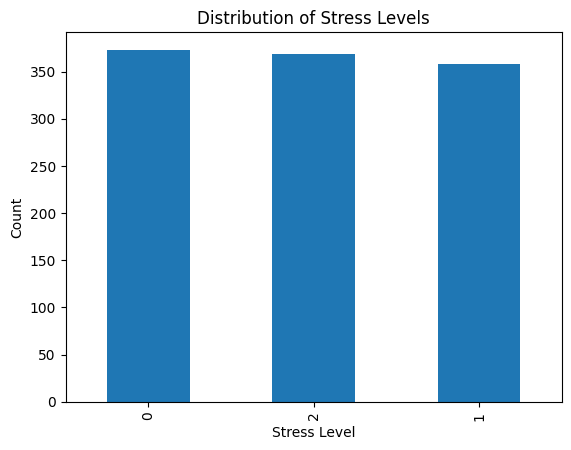

In [10]:
## make a bar plot to visualize the distribution of stress levels
import matplotlib.pyplot as plt

print("\nStress Level distribution:")
df['stress_level'].value_counts().plot(kind='bar')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.title('Distribution of Stress Levels')
plt.show()


En el *dataset* no se han encontrado valores nulos, ausentes, ni registros duplicados, y los tipos de datos son consistentes, ya que están en formato `int64` sin necesidad de conversión, así como la variable objetivo está bien balanceada ente las tres categorías, eso permitió usar *acurracy* como métrica confiable.

## Análisis de correlación

### Matriz de correlación
Se hizo un análisis de cómo se relacionan las variables entre sí y, en particular, cuáles tienen mayor asociación lineal con la variable objetivo `stress_level`. con el objetivo de identificar factores más influyentes y  detectar posible multicolinealidad entre predictores.

Primeramente se calculó la matriz de correlación de Pearson entre las 21 variables para identificar los factores asociados al nivel de estrés y detectar una posible multicolinealidad entre predictores.

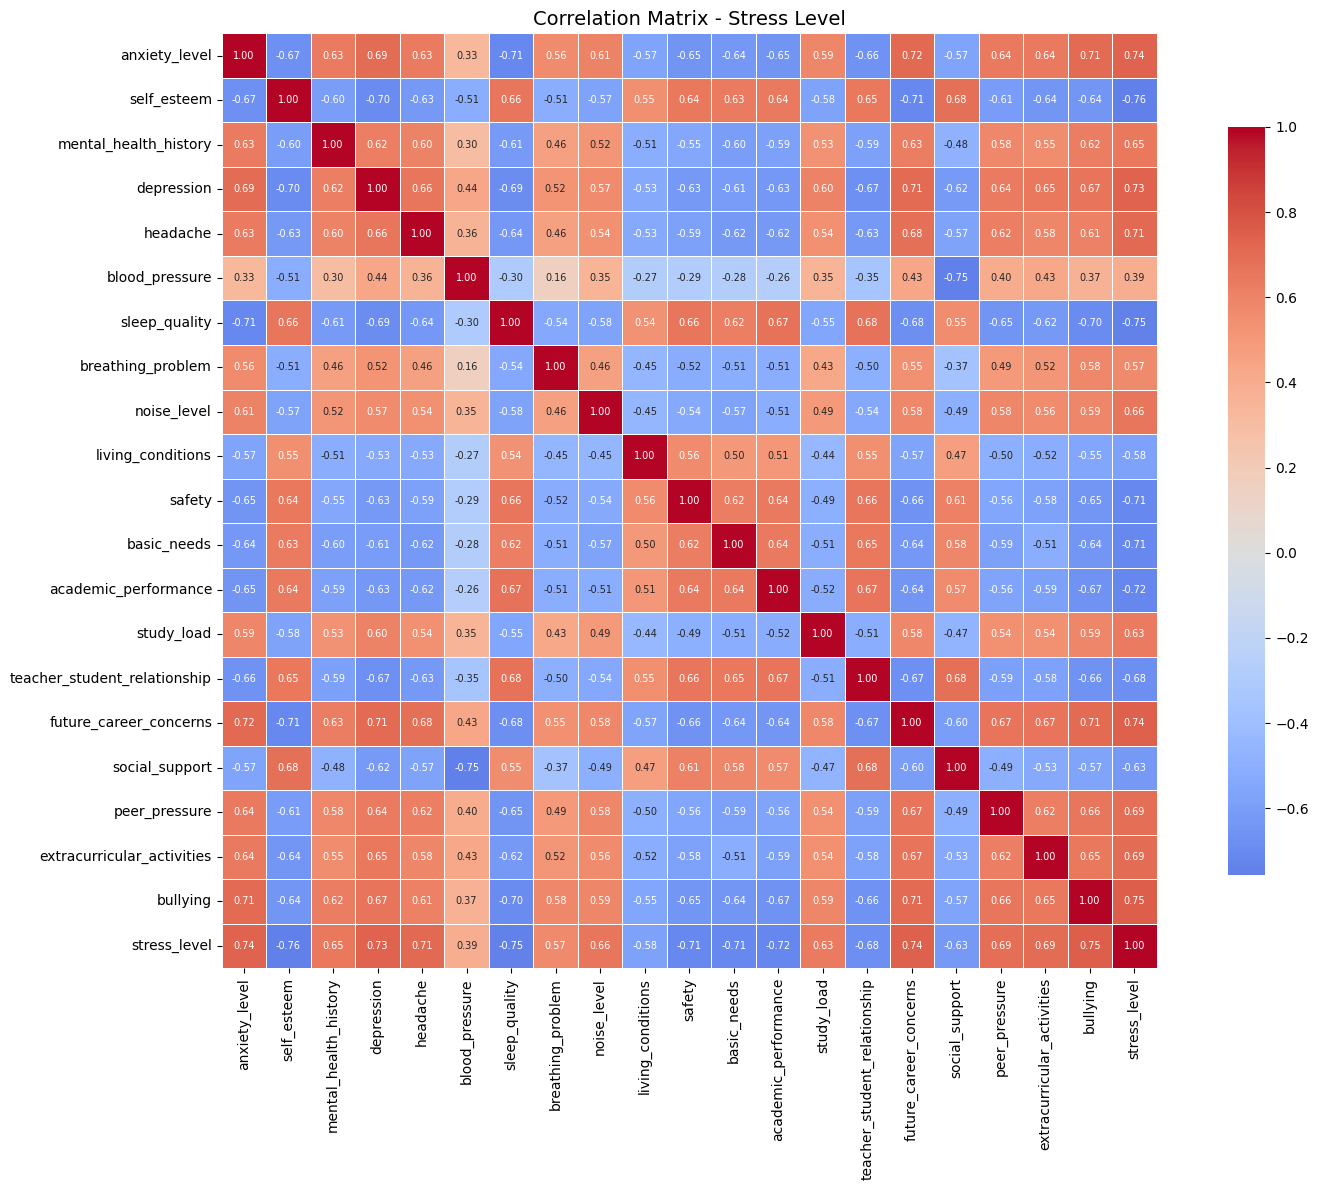

In [11]:
## Correlation matrix to visualize the relationship between features and stress level (Pearson)
corr_matrix = df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 7}
)
plt.title("Correlation Matrix - Stress Level", fontsize=14)
plt.tight_layout()
plt.show()



In [12]:
# Correlación de cada variable con la variable objetivo, ordenada de mayor a menor
target_corr = corr_matrix['stress_level'].drop('stress_level').sort_values(key=abs, ascending=False)
print("Correlación de cada variable con 'stress_level' (ordenada por magnitud):\n")
print(target_corr)

Correlación de cada variable con 'stress_level' (ordenada por magnitud):

self_esteem                    -0.756195
bullying                        0.751162
sleep_quality                  -0.749068
future_career_concerns          0.742619
anxiety_level                   0.736795
depression                      0.734379
academic_performance           -0.720922
headache                        0.713484
safety                         -0.709602
basic_needs                    -0.708968
extracurricular_activities      0.692977
peer_pressure                   0.690684
teacher_student_relationship   -0.680163
noise_level                     0.663371
mental_health_history           0.648644
study_load                      0.634156
social_support                 -0.632497
living_conditions              -0.581723
breathing_problem               0.573984
blood_pressure                  0.394200
Name: stress_level, dtype: float64


Todas las variables muestran una correlación fuerte con `stress_level`, con una **magnitud** entre *0.39 y 0.76*, este es un indicio temprano favorable para el modelado predictivo

### Multicolinealidad

Se visualizó con un gráfico de barras calculando la correlación con la variable objetivo y también la detección de posibles pares de variables con alta multicolinealidad `|r| > 0.7`

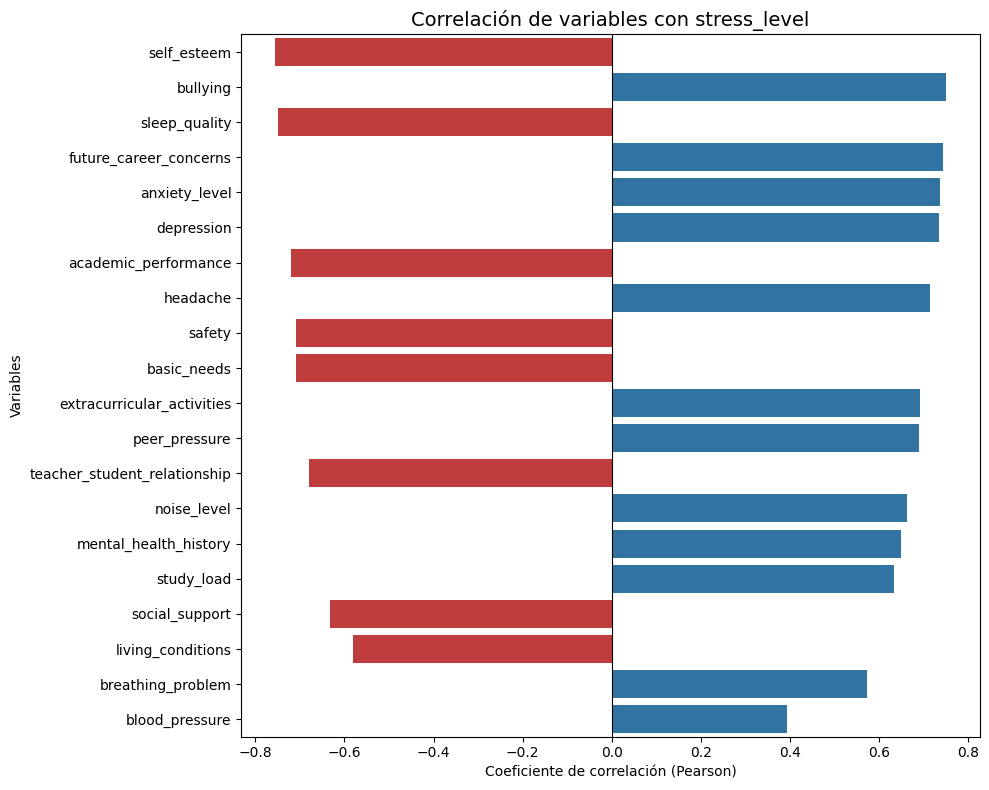

In [13]:
# Visualización: correlación con la variable objetivo
plt.figure(figsize=(10, 8))
colors = ['#d62728' if v < 0 else '#1f77b4' for v in target_corr.values]
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index,
            palette=colors, legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Correlación de variables con stress_level", fontsize=14)
plt.xlabel("Coeficiente de correlación (Pearson)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

In [14]:
# Detección de posibles pares de variables con alta multicolinealidad (|r| > 0.7), excluyendo la diagonal
high_corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ['variable_1', 'variable_2', 'correlacion']
high_corr_pairs = high_corr_pairs.reindex(
    high_corr_pairs['correlacion'].abs().sort_values(ascending=False).index
)
high_corr_pairs = high_corr_pairs[high_corr_pairs['correlacion'].abs() > 0.7]

print("Pares de variables con alta correlación (|r| > 0.7):\n")
print(high_corr_pairs.to_string(index=False) if not high_corr_pairs.empty else "No se encontraron pares con |r| > 0.7")

Pares de variables con alta correlación (|r| > 0.7):

            variable_1             variable_2  correlacion
           self_esteem           stress_level    -0.756195
        blood_pressure         social_support    -0.752531
              bullying           stress_level     0.751162
         sleep_quality           stress_level    -0.749068
future_career_concerns           stress_level     0.742619
         anxiety_level           stress_level     0.736795
            depression           stress_level     0.734379
  academic_performance           stress_level    -0.720922
         anxiety_level future_career_concerns     0.717016
              headache           stress_level     0.713484
           self_esteem future_career_concerns    -0.712520
future_career_concerns               bullying     0.711278
         anxiety_level          sleep_quality    -0.710292
         anxiety_level               bullying     0.709982
                safety           stress_level    -0.709602
  

#### Interpretación

- Las variables con mayor correlación (positiva o negativa) con `stress_level` son las candidatas más fuertes como predictoras y merecen atención especial en el modelado.
- Se identificaron pares de variables con `|r| > 0.7`
- Los pares de variables tienen relación con la variable objetivo, notablemente `blood_presssure`- `social_support` con un `|r| = -0.75` y `anxiety_level`- `future_career_concerns` con un `|r| = 0.72`


## Modelado

### Entrenamiento de algoritmos

Se construyó un modelo de clasificación para predecir `stress_level` (0 = bajo, 1 = medio, 2 = alto) a partir de las 20 variables predictoras, entrenando y comparando tres algoritmos de clasificación multiclase.

Se decició utilizar la **regresión logística multinomial** porque:

- El objetivo tiene 3 clases no ordenadas de forma estrictamente ordinal en el modelo (aunque conceptualmente sí lo son), y multinomial maneja bien este caso general.
- Es un modelo interpretable: los coeficientes indican dirección y fuerza de cada variable.
- Las clases están balanceadas (visto en el EDA), por lo que `accuracy` es una métrica confiable.
- El análisis de correlación previo no mostró multicolinealidad severa entre predictores, lo cual favorece la estabilidad de los coeficientes.

Para realizar el modelado, se importaron las librerías necesarias de `sklearn`

In [26]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#### Regresión logística multinomial

Modelo lineal interpretable, entrenado sobre variables estandarizadas (StandardScaler). Sirve como modelo base y como referencia interpretativa, ya que sus coeficientes indican dirección y magnitud del efecto de cada variable sobre cada clase.

In [16]:
# Separar variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=['stress_level'])
y = df['stress_level']

# División train/test estratificada (mantiene la proporción de clases en ambos conjuntos)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")
print("\nDistribución de clases en train:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nDistribución de clases en test:")
print(y_test.value_counts(normalize=True).sort_index())

Entrenamiento: 880 muestras
Prueba: 220 muestras

Distribución de clases en train:
stress_level
0    0.339773
1    0.325000
2    0.335227
Name: proportion, dtype: float64

Distribución de clases en test:
stress_level
0    0.336364
1    0.327273
2    0.336364
Name: proportion, dtype: float64


In [ ]:
# Escalado de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Entrenamiento del modelo de regresión logística multinomial
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [19]:
# Evaluación del modelo
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {acc:.4f}")
print(f"F1-score (macro): {f1_macro:.4f}\n")
print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

Accuracy: 0.8818
F1-score (macro): 0.8820

Reporte de clasificación:

              precision    recall  f1-score   support

    Bajo (0)       0.86      0.85      0.86        74
   Medio (1)       0.90      0.92      0.91        72
    Alto (2)       0.88      0.88      0.88        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



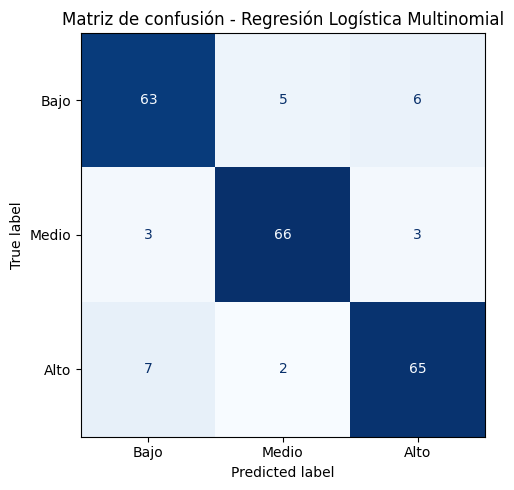

In [20]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bajo', 'Medio', 'Alto'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de confusión - Regresión Logística Multinomial')
plt.tight_layout()
plt.show()

En este matriz de confusión clasifica correctamente el 88.2% de los casos de prueba. Los errores se concentran principalmente entre clases adyacentes (bajo↔medio, medio↔alto), un patrón esperable dado el carácter ordinal subyacente de la variable, y no se observan confusiones graves entre las clases extremas (bajo↔alto).

In [21]:
# Validación cruzada estratificada (5 folds) para verificar estabilidad del modelo
X_scaled_full = scaler.fit_transform(X)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled_full, y, cv=cv, scoring='accuracy')

print(f"Accuracy por fold: {np.round(cv_scores, 4)}")
print(f"Accuracy promedio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Accuracy por fold: [0.9227 0.9045 0.8682 0.8682 0.8909]
Accuracy promedio: 0.8909 (+/- 0.0211)


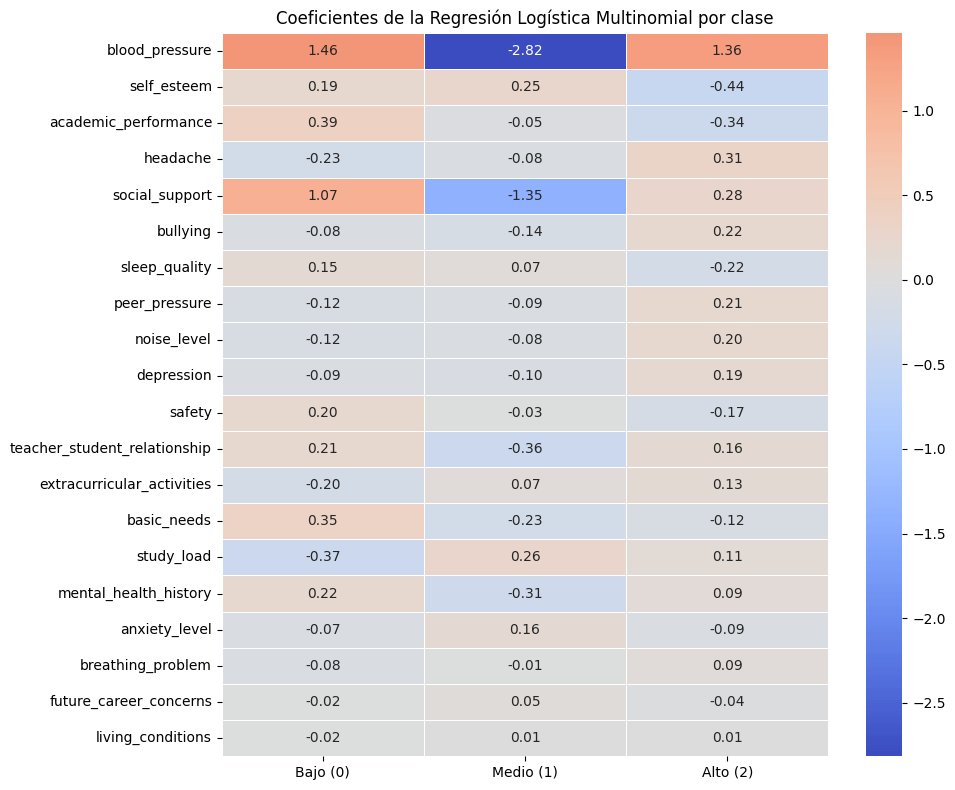

In [22]:
# Importancia/dirección de las variables según los coeficientes del modelo
# (un set de coeficientes por clase, ya que es multinomial)
coef_df = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=['Bajo (0)', 'Medio (1)', 'Alto (2)']
).T

# Ordenamos por la magnitud del efecto hacia la clase 'Alto'
coef_df_sorted = coef_df.reindex(coef_df['Alto (2)'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 8))
sns.heatmap(coef_df_sorted, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Coeficientes de la Regresión Logística Multinomial por clase')
plt.tight_layout()
plt.show()


Una vez logrado el modelo, se realizaron los dos entrenamientos del algoritmo, posteriormente, se procedió a comparar contra un modelo basado en árboles (Random Forest/Gradient Boosting) como benchmark no lineal.

#### Random Forest
Ensamble de 300 árboles de decisión por bagging, entrenado sobre variables sin escalar. Robusto frente a outliers y capaz de capturar interacciones no lineales entre variables.

In [27]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
print(f"Random Forest -> Accuracy: {acc_rf:.4f} | F1-macro: {f1_rf:.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

Random Forest -> Accuracy: 0.8864 | F1-macro: 0.8864

              precision    recall  f1-score   support

    Bajo (0)       0.90      0.85      0.88        74
   Medio (1)       0.89      0.92      0.90        72
    Alto (2)       0.87      0.89      0.88        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



#### Gradient Boosting
Ensamble secuencial de 300 árboles poco profundos (max_depth = 3, learning_rate = 0.05), entrenado sobre variables sin escalar. Suele lograr mayor precisión que Random Forest a costa de mayor sensibilidad al ajuste de hiperparámetros.

In [28]:
# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average='macro')
print(f"Gradient Boosting -> Accuracy: {acc_gb:.4f} | F1-macro: {f1_gb:.4f}\n")
print(classification_report(y_test, y_pred_gb, target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

Gradient Boosting -> Accuracy: 0.8636 | F1-macro: 0.8635

              precision    recall  f1-score   support

    Bajo (0)       0.87      0.82      0.85        74
   Medio (1)       0.87      0.92      0.89        72
    Alto (2)       0.85      0.85      0.85        74

    accuracy                           0.86       220
   macro avg       0.86      0.86      0.86       220
weighted avg       0.86      0.86      0.86       220



## Evaluación

### Comparación de desempeño

Se comparó la regresión logística multinomial contra dos modelos basados en árboles, que pueden capturar relaciones e interacciones no lineales entre variables sin necesitar escalado de datos:

Los modelos de árboles no requieren estandarización, por lo que se entrenan sobre `X_train`/`X_test` sin escalar.

In [33]:
# Validación cruzada (5 folds) para los tres modelos, sobre los mismos folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_logreg = cross_val_score(model, X_scaled_full, y, cv=cv, scoring='accuracy')
cv_rf = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')
cv_gb = cross_val_score(gb_model, X, y, cv=cv, scoring='accuracy')

print(f"Regresión Logística -> {cv_logreg.mean():.4f} (+/- {cv_logreg.std():.4f})")
print(f"Random Forest       -> {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")
print(f"Gradient Boosting   -> {cv_gb.mean():.4f} (+/- {cv_gb.std():.4f})")

Regresión Logística -> 0.8909 (+/- 0.0211)
Random Forest       -> 0.8736 (+/- 0.0150)
Gradient Boosting   -> 0.8909 (+/- 0.0199)


La siguiente tabla resume el desempeño de los tres modelos en el conjunto de prueba y en validación cruzada estratificada de 5 folds (esta última evalúa la estabilidad del modelo frente a distintas particiones de los datos):

In [34]:
# Tabla comparativa resumen
comparison = pd.DataFrame({
    'Modelo': ['Regresión Logística Multinomial', 'Random Forest', 'Gradient Boosting'],
    'Accuracy (test)': [acc, acc_rf, acc_gb],
    'F1-macro (test)': [f1_macro, f1_rf, f1_gb],
    'Accuracy CV (media)': [cv_logreg.mean(), cv_rf.mean(), cv_gb.mean()],
    'Accuracy CV (std)': [cv_logreg.std(), cv_rf.std(), cv_gb.std()],
}).round(4)

comparison


,Modelo,Accuracy (test),F1-macro (test),Accuracy CV (media),Accuracy CV (std)
0,Regresión Logística Multinomial,0.8818,0.8820,0.8909,0.0211
1,Random Forest,0.8864,0.8864,0.8736,0.0150
2,Gradient Boosting,0.8636,0.8635,0.8909,0.0199


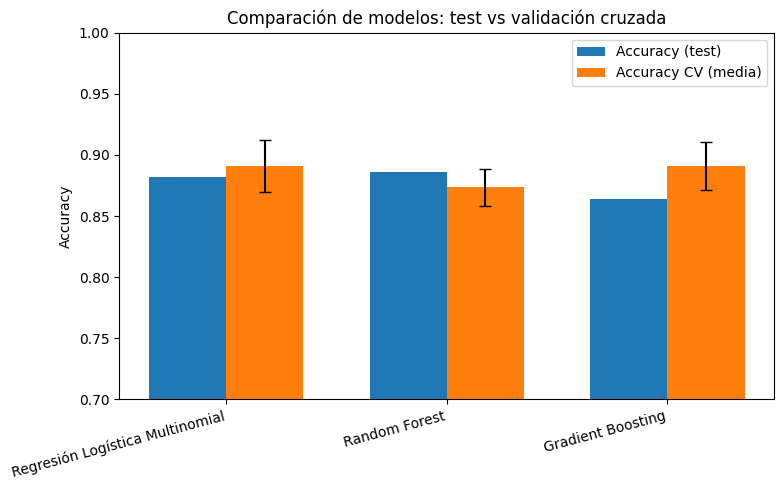

In [35]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(comparison))
width = 0.35

ax.bar(x_pos - width/2, comparison['Accuracy (test)'], width, label='Accuracy (test)')
ax.bar(x_pos + width/2, comparison['Accuracy CV (media)'], width, label='Accuracy CV (media)',
        yerr=comparison['Accuracy CV (std)'], capsize=4)
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison['Modelo'], rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.7, 1.0)
ax.set_title('Comparación de modelos: test vs validación cruzada')
ax.legend()
plt.tight_layout()
plt.show()

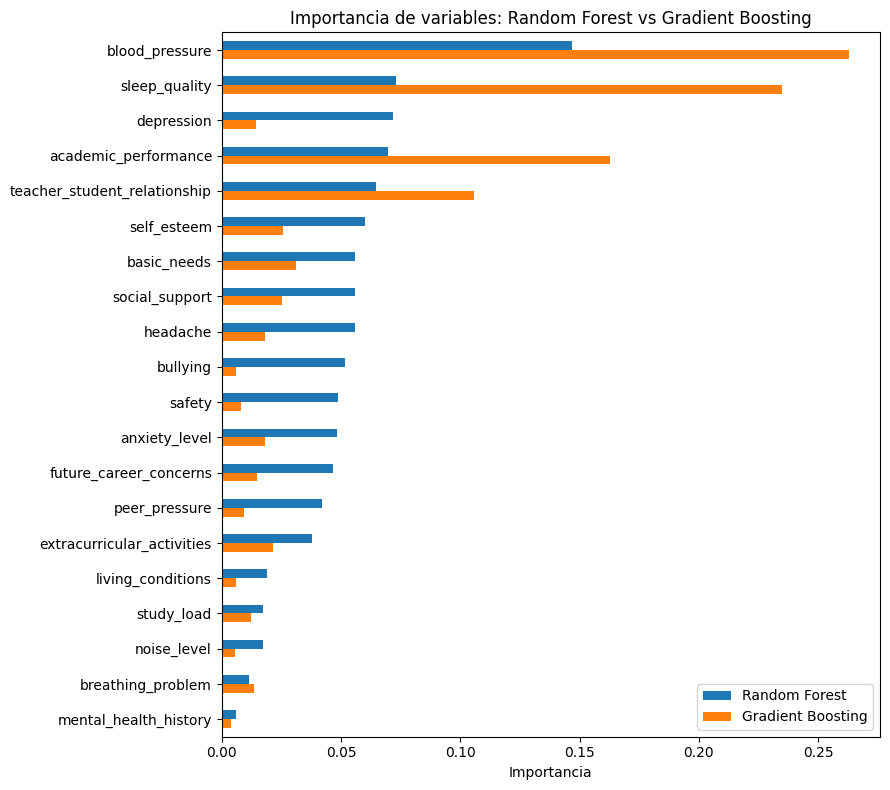

In [36]:
# Importancia de variables según Random Forest y Gradient Boosting
importances = pd.DataFrame({
    'Random Forest': rf_model.feature_importances_,
    'Gradient Boosting': gb_model.feature_importances_,
}, index=X.columns).sort_values('Random Forest', ascending=False)

importances.plot(kind='barh', figsize=(9, 8))
plt.title('Importancia de variables: Random Forest vs Gradient Boosting')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Las variables con mayor peso en los modelos de árboles coinciden en gran medida con las que mostraron mayor correlación en la Sección 3 (self_esteem, bullying, sleep_quality, anxiety_level, depression), lo que refuerza la confianza en que estos factores son realmente los más relevantes, independientemente del algoritmo utilizado.

### Interpretación general

- El desempeño equivalente entre los tres modelos (diferencias de 1-2 puntos porcentuales) indica que la relación entre los predictores y el nivel de estrés es predominantemente lineal/aditiva.
- Ningún modelo muestra señales de overfitting: el accuracy en test es consistente con el de validación cruzada en los tres casos.
- Random Forest presenta la menor varianza entre folds (± 1.5%), es decir, es el más estable, aunque no el de mayor accuracy promedio.
- Se cumple el criterio de éxito definido en la Sección 1.3 (accuracy y F1-macro > 80%, desempeño estable en validación cruzada) para los tres modelos.

## Despliegue

### Recomendaciones

Como modelo final, la regresión logística multinomial es la recomendada para desplegar, porque su desempeño es estadisticamente semejante al de los modelos de árboles. El hecho de que permite explicar cada predicción en términos de dirección y magnitud del efecto de cada factor muestra que su *Interpretabilidad* es su gran ventaja.

### Consideraciones

- Estandarización: se requiere que el modelo se transforme en sus variables de entrada con un `StandardScaler` ajustado en el entrenamiento
- Monitoreo: reevaluar periódicamente si se recolecta datos nuevos, ya que factores psicosociales pueden variar de población de acuerdo de su relación con el estrés

### Posibles pasos

- Ajuste de hiperparámetros mediante la búsqueda aleatoria
- Explorar reducción de dimensionalidad debido a el número de predictores altamente correlacionados entre sí.

## Conclusión

El proyecto siguió de forma completa el ciclo CRISP-DM:

1. Objetivo de negocio claro
2. Validación de calidad y balance de datos
3. Identificación de factores más asociados al estrés por análisis de correlación
4. Comparación de tres enfoques de modelado

La convergencia de resultados de un modelo lineal contra dos modelos de árboles, junto con la coincidencia de las variables más importantes, muestra una base sólida y bien fundamentada para el modelo final recomendado para su aplicación.